# Analysis of Student Exam Performance and Exam Success Status Dataset

## Kurasi Data (lewat API Kaggle)

### Mengimpor Library Penting

In [1]:
import os
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Mengunduh Dataset Lewat API Kaggle

In [2]:
path = kagglehub.dataset_download("mobeenfatimah/student-exam-performance-and-success-dataset")
print("Path to dataset files:", path)

all_files = [os.path.join(path, item) for item in os.listdir(path)]
csv_path = None
for item in all_files:
    filename = os.path.basename(item)
    if os.path.isfile(item) and os.path.splitext(filename)[1] == ".csv":
        csv_path = item
        print(f"\nFound the CSV file at {item}.")
        break
    
if csv_path is None:
    raise FileNotFoundError("The CSV path couldn't be found.")

Path to dataset files: /home/zico/.cache/kagglehub/datasets/mobeenfatimah/student-exam-performance-and-success-dataset/versions/1

Found the CSV file at /home/zico/.cache/kagglehub/datasets/mobeenfatimah/student-exam-performance-and-success-dataset/versions/1/student_exam_performance.csv.


### Memuat Dataset dan Menampilkan Atributnya

In [3]:
data = pd.read_csv(csv_path).drop(columns=["student_id"])
data.info()
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 43 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   age                         100000 non-null  int64  
 1   gender                      100000 non-null  str    
 2   education_level             100000 non-null  str    
 3   school_type                 100000 non-null  str    
 4   family_income               100000 non-null  str    
 5   parent_education            93474 non-null   str    
 6   urban_rural                 100000 non-null  str    
 7   previous_exam_score         100000 non-null  float64
 8   previous_gpa                92207 non-null   float64
 9   attendance_percentage       90137 non-null   float64
 10  assignment_completion_rate  100000 non-null  float64
 11  class_participation         100000 non-null  str    
 12  study_hours_per_day         100000 non-null  float64
 13  self_study_hours          

,age,previous_exam_score,previous_gpa,attendance_percentage,assignment_completion_rate,study_hours_per_day,self_study_hours,private_tuition,online_learning_hours,practice_tests_completed,...,physical_activity_hours,stress_level,internet_access,online_course_hours,exam_preparation_days,questions_attempted,questions_correct,time_management_score,exam_anxiety_level,exam_score
count,100000.000000,100000.000000,92207.000000,90137.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,90387.000000,100000.000000,100000.000000
mean,17.005740,69.531033,2.780892,84.616882,69.724405,2.995725,2.094970,0.299800,2.004763,5.509170,...,2.487579,9.375640,0.918760,2.999453,15.501440,92.492150,57.298240,78.398551,8.927373,61.950072
std,1.999562,11.379108,0.478218,7.922485,12.127179,1.719466,1.266066,0.458173,2.005719,2.501131,...,2.413386,1.081613,0.273205,2.983732,8.644356,4.609376,15.028787,14.105155,1.354875,15.863644
min,14.000000,30.000000,1.000000,46.340000,20.000000,0.500000,0.250000,0.000000,0.000000,0.000000,...,0.000000,5.000000,0.000000,0.000000,1.000000,85.000000,0.000000,17.030000,1.000000,0.000000
25%,15.000000,61.820000,2.460000,79.210000,61.480000,1.720000,1.170000,0.000000,0.580000,4.000000,...,0.720000,9.000000,1.000000,0.860000,8.000000,88.000000,47.000000,68.790000,8.220000,51.240000
50%,17.000000,69.530000,2.780000,84.750000,69.570000,2.670000,1.840000,0.000000,1.380000,5.000000,...,1.730000,10.000000,1.000000,2.080000,16.000000,92.000000,57.000000,79.000000,9.490000,61.960000
75%,19.000000,77.232500,3.110000,90.170000,77.920000,3.910000,2.730000,1.000000,2.770000,7.000000,...,3.480000,10.000000,1.000000,4.150000,23.000000,96.000000,67.000000,89.210000,10.000000,72.730000
max,20.000000,100.000000,4.000000,100.000000,100.000000,12.000000,10.000000,1.000000,15.000000,20.000000,...,12.000000,10.000000,1.000000,20.000000,30.000000,100.000000,100.000000,100.000000,10.000000,100.000000


### Melihat Kolom yang Ada

In [4]:
attribute_types = {
    "nominal": [
        "gender",
        "school_type",
        "urban_rural",
        "study_method",
        "study_environment",
        "device_availability",
        "pass_status"
    ],
    "ordinal": [
        "education_level",
        "family_income",
        "parent_education",
        "class_participation",
        "study_consistency",
        "revision_frequency",
        "notes_quality",
        "sleep_quality",
        "break_frequency",
        "motivation_level",
        "educational_app_usage",
        "exam_difficulty",
        "performance_grade",
        "performance_level"
    ],
    "numerical": [
        "age",
        "previous_exam_score",
        "previous_gpa",
        "attendance_percentage",
        "assignment_completion_rate",
        "study_hours_per_day",
        "self_study_hours",
        "private_tuition",
        "online_learning_hours",
        "practice_tests_completed",
        "sleep_hours",
        "daily_screen_time",
        "physical_activity_hours",
        "stress_level",
        "internet_access",
        "online_course_hours",
        "exam_preparation_days",
        "questions_attempted",
        "questions_correct",
        "time_management_score",
        "exam_anxiety_level",
        "exam_score"
    ]
}
cols = data.columns

for col in cols:
    col_data = data[col]
    print(f"First 10 unique values of {col} column:")
    print(col_data.dtype)
    print(", ".join(list(map(str, col_data.unique()[:10]))))
    print()

First 10 unique values of age column:
int64
20, 17, 18, 16, 15, 19, 14

First 10 unique values of gender column:
str
Female, Male, Other

First 10 unique values of education_level column:
str
High School, Undergraduate

First 10 unique values of school_type column:
str
Public, Private, Charter

First 10 unique values of family_income column:
str
Middle, High, Lower-Middle, Upper-Middle, Low

First 10 unique values of parent_education column:
str
nan, Master, High School, Bachelor, Associate, Doctorate

First 10 unique values of urban_rural column:
str
Rural, Suburban, Urban

First 10 unique values of previous_exam_score column:
float64
78.36, 73.4, 82.76, 60.61, 74.79, 67.68, 78.84, 90.79, 61.28, 61.33

First 10 unique values of previous_gpa column:
float64
2.95, 2.89, 3.35, 2.57, 2.84, nan, 3.0, 3.63, 2.43, 2.72

First 10 unique values of attendance_percentage column:
float64
81.49, nan, 100.0, 84.91, 88.21, 97.11, 85.38, 80.61, 86.47, 89.61

First 10 unique values of assignment_compl

### Menampilkan Kolom yang Memiliki Nilai NaN

In [5]:
nan_masking   = data.isna().any(axis=0)
cols_with_nan = nan_masking.loc[nan_masking == True]

print("Columns with NaN values:")
print(cols_with_nan)

Columns with NaN values:
parent_education         True
previous_gpa             True
attendance_percentage    True
notes_quality            True
sleep_quality            True
device_availability      True
time_management_score    True
dtype: bool


### Menampilkan Baris yang Memiliki Nilai NaN

In [23]:
nan_rows = data[data.isna().any(axis=1)]
print(f"Rows with NaN values ({len(nan_rows)} rows):")
nan_rows

Rows with NaN values (41940 rows):


,age,gender,education_level,school_type,family_income,parent_education,urban_rural,previous_exam_score,previous_gpa,attendance_percentage,assignment_completion_rate,class_participation,study_hours_per_day,self_study_hours,private_tuition,online_learning_hours,study_consistency,study_environment,study_method,revision_frequency,practice_tests_completed,notes_quality,sleep_hours,sleep_quality,daily_screen_time,physical_activity_hours,break_frequency,stress_level,motivation_level,internet_access,device_availability,educational_app_usage,online_course_hours,exam_difficulty,exam_preparation_days,questions_attempted,questions_correct,time_management_score,exam_anxiety_level,exam_score,performance_grade,pass_status,performance_level
0,20,Female,High School,Public,Middle,NaN,Rural,78.36,2.95,81.49,65.18,Medium,4.94,2.63,0,1.75,Medium,Moderate,Flashcards,Rarely,8,Average,6.31,Excellent,3.80,0.93,Frequently,10,High,1,Shared,Low,2.15,Medium,27,95,86,NaN,9.39,90.40,A,Pass,High
1,17,Male,High School,Public,Middle,NaN,Suburban,73.40,2.89,NaN,76.53,Low,3.42,2.64,0,1.97,Medium,Moderate,Flashcards,Daily,10,Average,6.81,Excellent,4.04,0.21,Frequently,8,High,1,Shared,Moderate,4.37,Easy,4,100,86,87.17,6.31,86.21,A,Pass,High
5,18,Male,High School,Public,High,High School,Rural,67.68,NaN,97.11,65.46,Medium,3.18,1.67,1,1.02,Medium,Quiet,Self-Reading,Daily,6,Average,8.83,Fair,8.37,1.64,Occasionally,6,Medium,1,Shared,Moderate,1.08,Hard,27,96,65,55.27,6.12,67.90,C,Pass,Medium
6,18,Male,High School,Charter,Middle,NaN,Urban,78.84,3.00,85.38,70.92,Medium,3.35,2.11,0,1.47,Medium,Quiet,Practice Tests,Weekly,6,Average,7.16,Fair,2.59,0.71,Occasionally,10,Medium,1,Dedicated,Low,5.62,Hard,12,98,54,86.15,9.46,53.86,D,Pass,Low
10,20,Male,High School,Private,Middle,Doctorate,Suburban,71.70,2.86,84.73,64.63,High,1.47,1.04,1,3.47,Low,Quiet,Self-Reading,Daily,4,Average,9.10,Fair,2.63,3.80,Frequently,6,Medium,1,Shared,Moderate,0.64,Medium,2,93,68,NaN,4.59,76.22,B,Pass,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99990,15,Female,High School,Public,Middle,Bachelor,Rural,75.68,2.75,NaN,52.31,High,2.49,1.88,0,0.70,Medium,Noisy,Practice Tests,Daily,8,Poor,7.88,Poor,4.98,5.65,Rarely,8,Low,1,Dedicated,Moderate,0.65,Medium,11,95,53,73.19,10.00,55.31,D,Pass,Low
99993,17,Male,High School,Public,Upper-Middle,High School,Urban,86.48,3.64,NaN,80.45,High,2.49,1.69,0,5.63,Medium,Quiet,Group Study,Daily,5,Excellent,6.26,Fair,8.67,0.46,Frequently,10,High,0,Dedicated,High,2.33,Easy,22,91,73,74.99,6.92,80.46,B,Pass,High
99995,17,Male,Undergraduate,Public,Upper-Middle,NaN,Suburban,78.73,NaN,89.67,60.97,High,1.16,0.68,0,1.56,Medium,Moderate,Flashcards,Weekly,7,Average,7.00,Fair,7.69,4.29,Occasionally,8,Medium,1,Shared,High,6.43,Medium,5,95,62,76.13,8.36,66.46,C,Pass,Medium
99996,14,Female,High School,Public,Upper-Middle,Bachelor,Suburban,75.70,2.98,83.87,94.38,Medium,8.59,6.63,0,0.49,Medium,Noisy,Group Study,Weekly,12,NaN,6.73,Excellent,2.57,3.60,Frequently,10,Low,1,Dedicated,Low,4.34,Easy,24,94,91,84.29,8.68,96.54,A,Pass,High


## Exploratory Data Analysis (EDA)

Bagian berikut melakukan eksplorasi data secara menyeluruh terhadap dataframe `data`: statistik deskriptif, distribusi tiap atribut, deteksi outlier, serta hubungan antar atribut (univariat dan bivariat). Interpretasi di bawah setiap grafik dihitung langsung dari data (bukan teks statis), sehingga akan menyesuaikan diri bila notebook dijalankan ulang dengan data yang diperbarui.

In [7]:
from IPython.display import display
import math

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

numerical_cols = attribute_types["numerical"]
categorical_cols = attribute_types["nominal"] + attribute_types["ordinal"]

### 1. Statistik Deskriptif untuk Atribut Numerik

Menghitung rata-rata (mean), median, modus, standar deviasi, serta nilai minimum dan maksimum untuk setiap atribut numerik.

In [8]:
desc_stats = pd.DataFrame({
    "mean": data[numerical_cols].mean(),
    "median": data[numerical_cols].median(),
    "mode": data[numerical_cols].mode().iloc[0],
    "std": data[numerical_cols].std(),
    "min": data[numerical_cols].min(),
    "max": data[numerical_cols].max(),
}).round(2)

print("Statistik deskriptif atribut numerik:")
display(desc_stats)

most_variable = desc_stats["std"].sort_values(ascending=False).index[0]
print(f"Interpretasi: Atribut dengan variasi antar-siswa paling besar adalah '{most_variable}' "
      f"(std = {desc_stats.loc[most_variable, 'std']}). Nilai mean dan median yang berdekatan pada "
      f"sebagian besar atribut mengindikasikan distribusi yang relatif simetris, sementara selisih "
      f"besar antara mean dan median pada atribut tertentu mengindikasikan adanya kemencengan (skew) "
      f"distribusi, yang akan dikonfirmasi lebih lanjut pada bagian histogram di bawah.")

Statistik deskriptif atribut numerik:


,mean,median,mode,std,min,max
age,17.01,17.00,17.00,2.00,14.00,20.00
previous_exam_score,69.53,69.53,100.00,11.38,30.00,100.00
previous_gpa,2.78,2.78,2.78,0.48,1.00,4.00
attendance_percentage,84.62,84.75,100.00,7.92,46.34,100.00
assignment_completion_rate,69.72,69.57,100.00,12.13,20.00,100.00
study_hours_per_day,3.00,2.67,0.50,1.72,0.50,12.00
self_study_hours,2.09,1.84,1.20,1.27,0.25,10.00
private_tuition,0.30,0.00,0.00,0.46,0.00,1.00
online_learning_hours,2.00,1.38,0.06,2.01,0.00,15.00
practice_tests_completed,5.51,5.00,5.00,2.50,0.00,20.00


Interpretasi: Atribut dengan variasi antar-siswa paling besar adalah 'exam_score' (std = 15.86). Nilai mean dan median yang berdekatan pada sebagian besar atribut mengindikasikan distribusi yang relatif simetris, sementara selisih besar antara mean dan median pada atribut tertentu mengindikasikan adanya kemencengan (skew) distribusi, yang akan dikonfirmasi lebih lanjut pada bagian histogram di bawah.


### 2. Frekuensi / Distribusi untuk Atribut Kategorikal

Menghitung frekuensi (jumlah) dan persentase kemunculan tiap kategori pada atribut nominal dan ordinal.

In [9]:
for col in categorical_cols:
    freq = data[col].value_counts(dropna=False)
    pct = (data[col].value_counts(normalize=True, dropna=False) * 100).round(2)
    freq_table = pd.DataFrame({"frekuensi": freq, "persentase (%)": pct})
    print(f"Distribusi kategori untuk kolom '{col}':")
    display(freq_table)
    print()

Distribusi kategori untuk kolom 'gender':


,frekuensi,persentase (%)
gender,,
Male,49130,49.13
Female,48841,48.84
Other,2029,2.03



Distribusi kategori untuk kolom 'school_type':


,frekuensi,persentase (%)
school_type,,
Public,55105,55.10
Private,34916,34.92
Charter,9979,9.98



Distribusi kategori untuk kolom 'urban_rural':


...

,frekuensi,persentase (%)
exam_difficulty,,
Medium,50242,50.24
Hard,24996,25.00
Easy,24762,24.76



Distribusi kategori untuk kolom 'performance_grade':


,frekuensi,persentase (%)
performance_grade,,
D,34886,34.89
F,22611,22.61
C,21794,21.79
B,13190,13.19
A,7519,7.52



Distribusi kategori untuk kolom 'performance_level':


,frekuensi,persentase (%)
performance_level,,
Low,45123,45.12
Medium,41999,42.00
High,12878,12.88


### 3. Identifikasi Jumlah Nilai yang Hilang (Missing Values)

Menghitung jumlah dan persentase nilai yang hilang (NaN) pada setiap atribut.

Ringkasan nilai yang hilang per atribut:


,jumlah_missing,persentase_missing (%)
attendance_percentage,9863,9.86
time_management_score,9613,9.61
notes_quality,8407,8.41
previous_gpa,7793,7.79
sleep_quality,6994,6.99
parent_education,6526,6.53
device_availability,2965,2.96


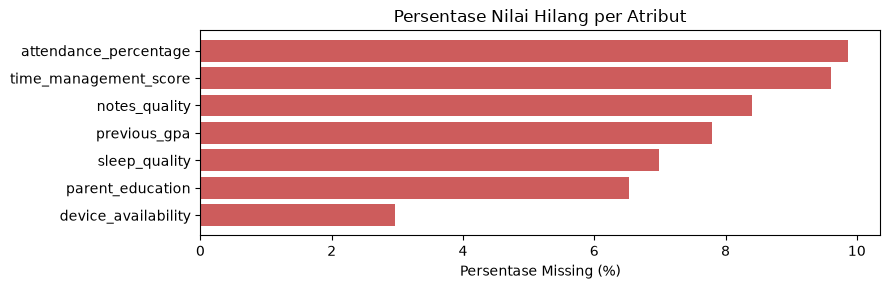

Interpretasi: Terdapat 7 atribut yang memiliki nilai hilang. Atribut dengan persentase missing tertinggi adalah 'attendance_percentage' sebesar 9.86%. Atribut dengan tingkat missing di atas 5% sebaiknya ditangani secara khusus (imputasi atau dianalisis terpisah) sebelum digunakan dalam pemodelan, karena berpotensi mempengaruhi validitas hasil analisis.


In [10]:
missing_count = data.isna().sum()
missing_pct = (data.isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "jumlah_missing": missing_count,
    "persentase_missing (%)": missing_pct,
})
missing_summary = missing_summary[missing_summary["jumlah_missing"] > 0].sort_values(
    "jumlah_missing", ascending=False
)

print("Ringkasan nilai yang hilang per atribut:")
display(missing_summary)

if len(missing_summary) > 0:
    fig, ax = plt.subplots(figsize=(9, max(3, 0.4 * len(missing_summary))))
    ax.barh(missing_summary.index, missing_summary["persentase_missing (%)"], color="indianred")
    ax.set_xlabel("Persentase Missing (%)")
    ax.set_title("Persentase Nilai Hilang per Atribut")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

    top_col = missing_summary.index[0]
    top_pct = missing_summary.iloc[0]["persentase_missing (%)"]
    print(f"Interpretasi: Terdapat {len(missing_summary)} atribut yang memiliki nilai hilang. "
          f"Atribut dengan persentase missing tertinggi adalah '{top_col}' sebesar {top_pct}%. "
          f"Atribut dengan tingkat missing di atas 5% sebaiknya ditangani secara khusus (imputasi "
          f"atau dianalisis terpisah) sebelum digunakan dalam pemodelan, karena berpotensi "
          f"mempengaruhi validitas hasil analisis.")
else:
    print("Interpretasi: Tidak ditemukan nilai yang hilang pada dataset ini.")

### 4. Deteksi Outlier pada Atribut Numerik (Metode IQR)

Sebuah nilai dianggap outlier jika berada di bawah Q1 - 1.5x IQR atau di atas Q3 + 1.5x IQR.

In [11]:
def detect_outliers_iqr(series):
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = int(((s < lower) | (s > upper)).sum())
    return n_outliers, lower, upper, len(s)

outlier_rows = []
for col in numerical_cols:
    n_outliers, lower, upper, n_valid = detect_outliers_iqr(data[col])
    outlier_rows.append({
        "atribut": col,
        "jumlah_outlier": n_outliers,
        "persentase_outlier (%)": round(n_outliers / n_valid * 100, 2) if n_valid else 0,
        "batas_bawah": round(lower, 2),
        "batas_atas": round(upper, 2),
    })

outlier_df = pd.DataFrame(outlier_rows).sort_values("jumlah_outlier", ascending=False).reset_index(drop=True)
print("Ringkasan deteksi outlier (metode IQR):")
display(outlier_df)

top_outlier = outlier_df.iloc[0]
print(f"Interpretasi: Atribut dengan jumlah outlier terbanyak adalah '{top_outlier['atribut']}' "
      f"({top_outlier['jumlah_outlier']} data, {top_outlier['persentase_outlier (%)']}%), dengan nilai "
      f"di luar rentang [{top_outlier['batas_bawah']}, {top_outlier['batas_atas']}] dianggap outlier. "
      f"Atribut dengan proporsi outlier tinggi perlu diperiksa lebih lanjut untuk menentukan apakah "
      f"nilai tersebut merupakan kesalahan input data atau variasi alami yang tetap valid, sebelum "
      f"diputuskan untuk dihapus, di-cap, atau ditransformasi.")

Ringkasan deteksi outlier (metode IQR):


,atribut,jumlah_outlier,persentase_outlier (%),batas_bawah,batas_atas
0,stress_level,10038,10.04,7.50,11.50
1,internet_access,8124,8.12,1.00,1.00
2,online_learning_hours,4959,4.96,-2.70,6.06
3,online_course_hours,4885,4.88,-4.08,9.09
4,physical_activity_hours,4855,4.86,-3.42,7.62
5,self_study_hours,2971,2.97,-1.17,5.07
6,exam_anxiety_level,2901,2.90,5.55,12.67
7,study_hours_per_day,2587,2.59,-1.57,7.20
8,practice_tests_completed,1724,1.72,-0.50,11.50
9,sleep_hours,672,0.67,3.74,10.26


Interpretasi: Atribut dengan jumlah outlier terbanyak adalah 'stress_level' (10038 data, 10.04%), dengan nilai di luar rentang [7.5, 11.5] dianggap outlier. Atribut dengan proporsi outlier tinggi perlu diperiksa lebih lanjut untuk menentukan apakah nilai tersebut merupakan kesalahan input data atau variasi alami yang tetap valid, sebelum diputuskan untuk dihapus, di-cap, atau ditransformasi.


### 5. Analisis Univariat

#### 5a. Histogram untuk Atribut Numerik

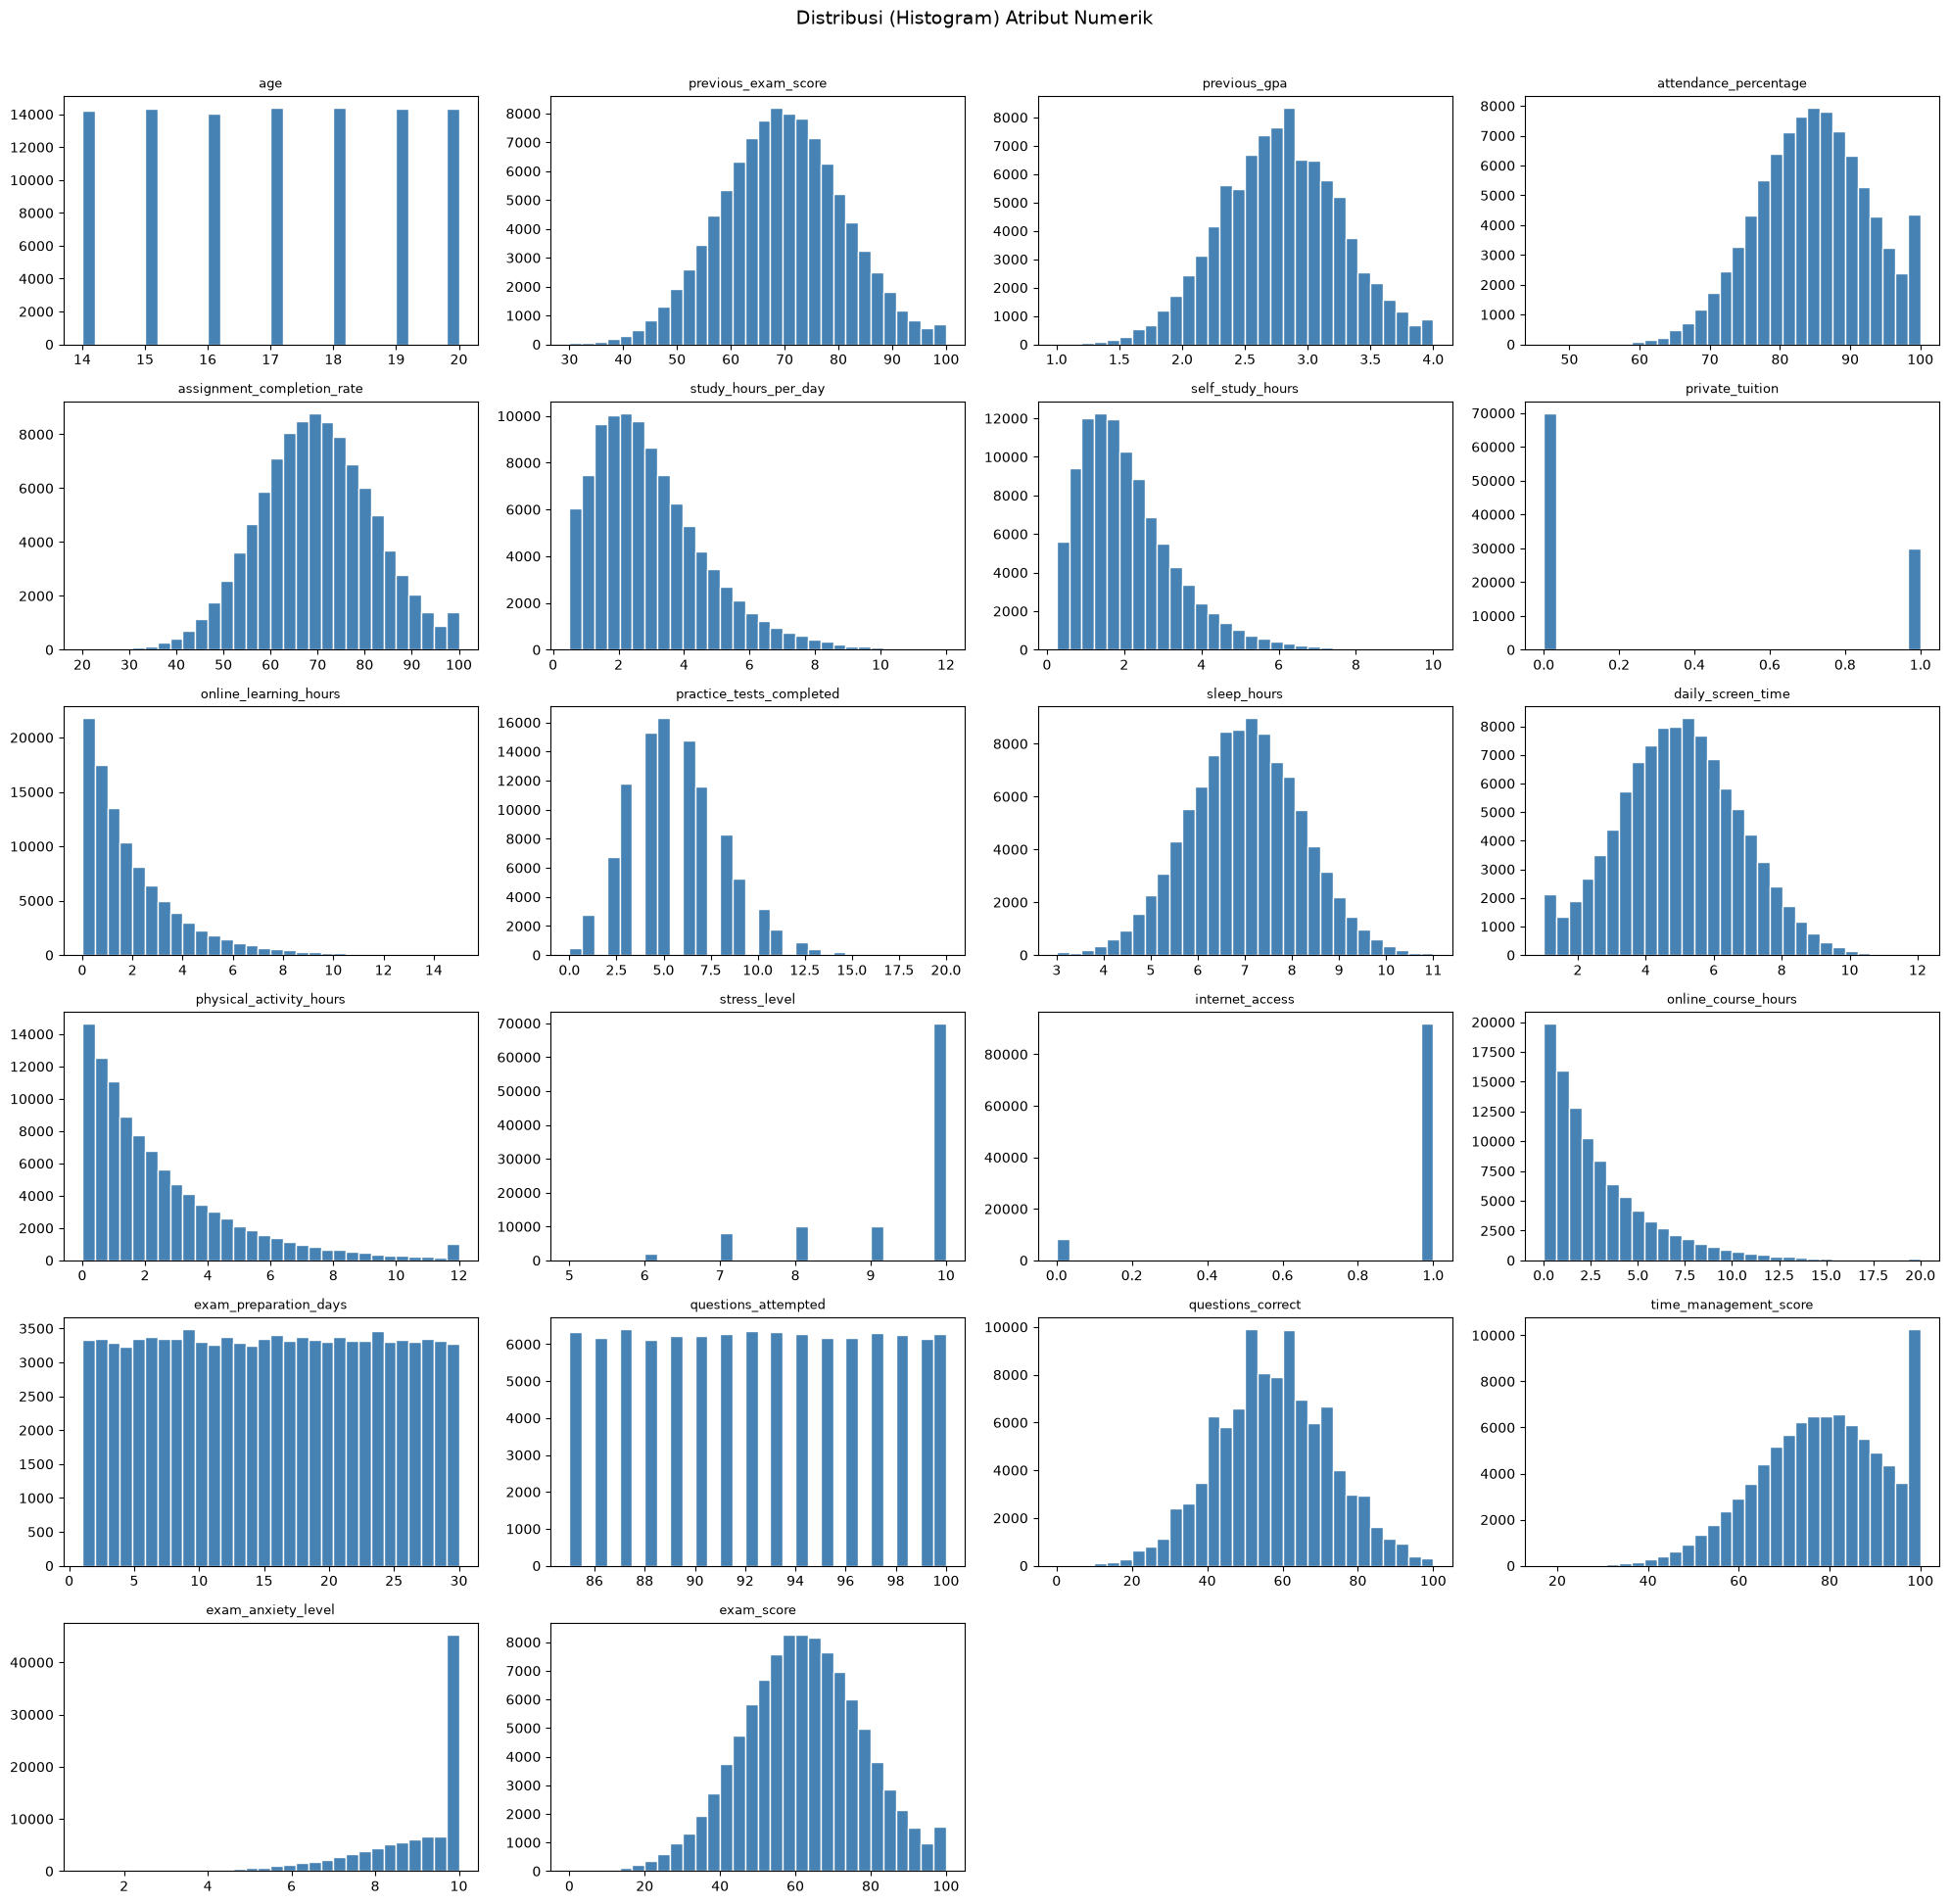

Skewness (kemencengan distribusi) tiap atribut, diurutkan dari yang paling condong:
internet_access              -3.07
online_learning_hours         1.95
online_course_hours           1.90
physical_activity_hours       1.62
stress_level                 -1.58
exam_anxiety_level           -1.42
self_study_hours              1.29
study_hours_per_day           1.13
private_tuition               0.87
practice_tests_completed      0.54
time_management_score        -0.35
attendance_percentage        -0.17
daily_screen_time             0.08
exam_score                   -0.06
previous_gpa                 -0.02
assignment_completion_rate    0.01
questions_correct            -0.01
previous_exam_score          -0.01
age                          -0.01
sleep_hours                  -0.00
questions_attempted           0.00
exam_preparation_days        -0.00
dtype: float64

Interpretasi: Sebagian besar atribut numerik memiliki distribusi yang relatif mendekati simetris (skewness mendekati 0). Atribut p

In [12]:
n_cols = 4
n_rows = math.ceil(len(numerical_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.2 * n_rows))
axes = axes.flatten()

skewness = {}
for i, col in enumerate(numerical_cols):
    values = data[col].dropna()
    axes[i].hist(values, bins=30, color="steelblue", edgecolor="white")
    axes[i].set_title(col, fontsize=9)
    skewness[col] = values.skew()

for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Distribusi (Histogram) Atribut Numerik", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

skew_series = pd.Series(skewness).reindex(pd.Series(skewness).abs().sort_values(ascending=False).index)
print("Skewness (kemencengan distribusi) tiap atribut, diurutkan dari yang paling condong:")
print(skew_series.round(2))

most_skewed = skew_series.index[0]
most_skewed_val = skew_series.iloc[0]
arah = "condong ke kanan (right-skewed)" if most_skewed_val > 0 else "condong ke kiri (left-skewed)"
print(f"\nInterpretasi: Sebagian besar atribut numerik memiliki distribusi yang relatif mendekati "
      f"simetris (skewness mendekati 0). Atribut paling condong adalah '{most_skewed}' dengan "
      f"skewness {most_skewed_val:.2f}, yaitu {arah}. Ini menunjukkan ada sebagian kecil siswa dengan "
      f"nilai jauh berbeda dari mayoritas pada atribut tersebut.")

#### 5b. Bar Chart untuk Atribut Kategorikal

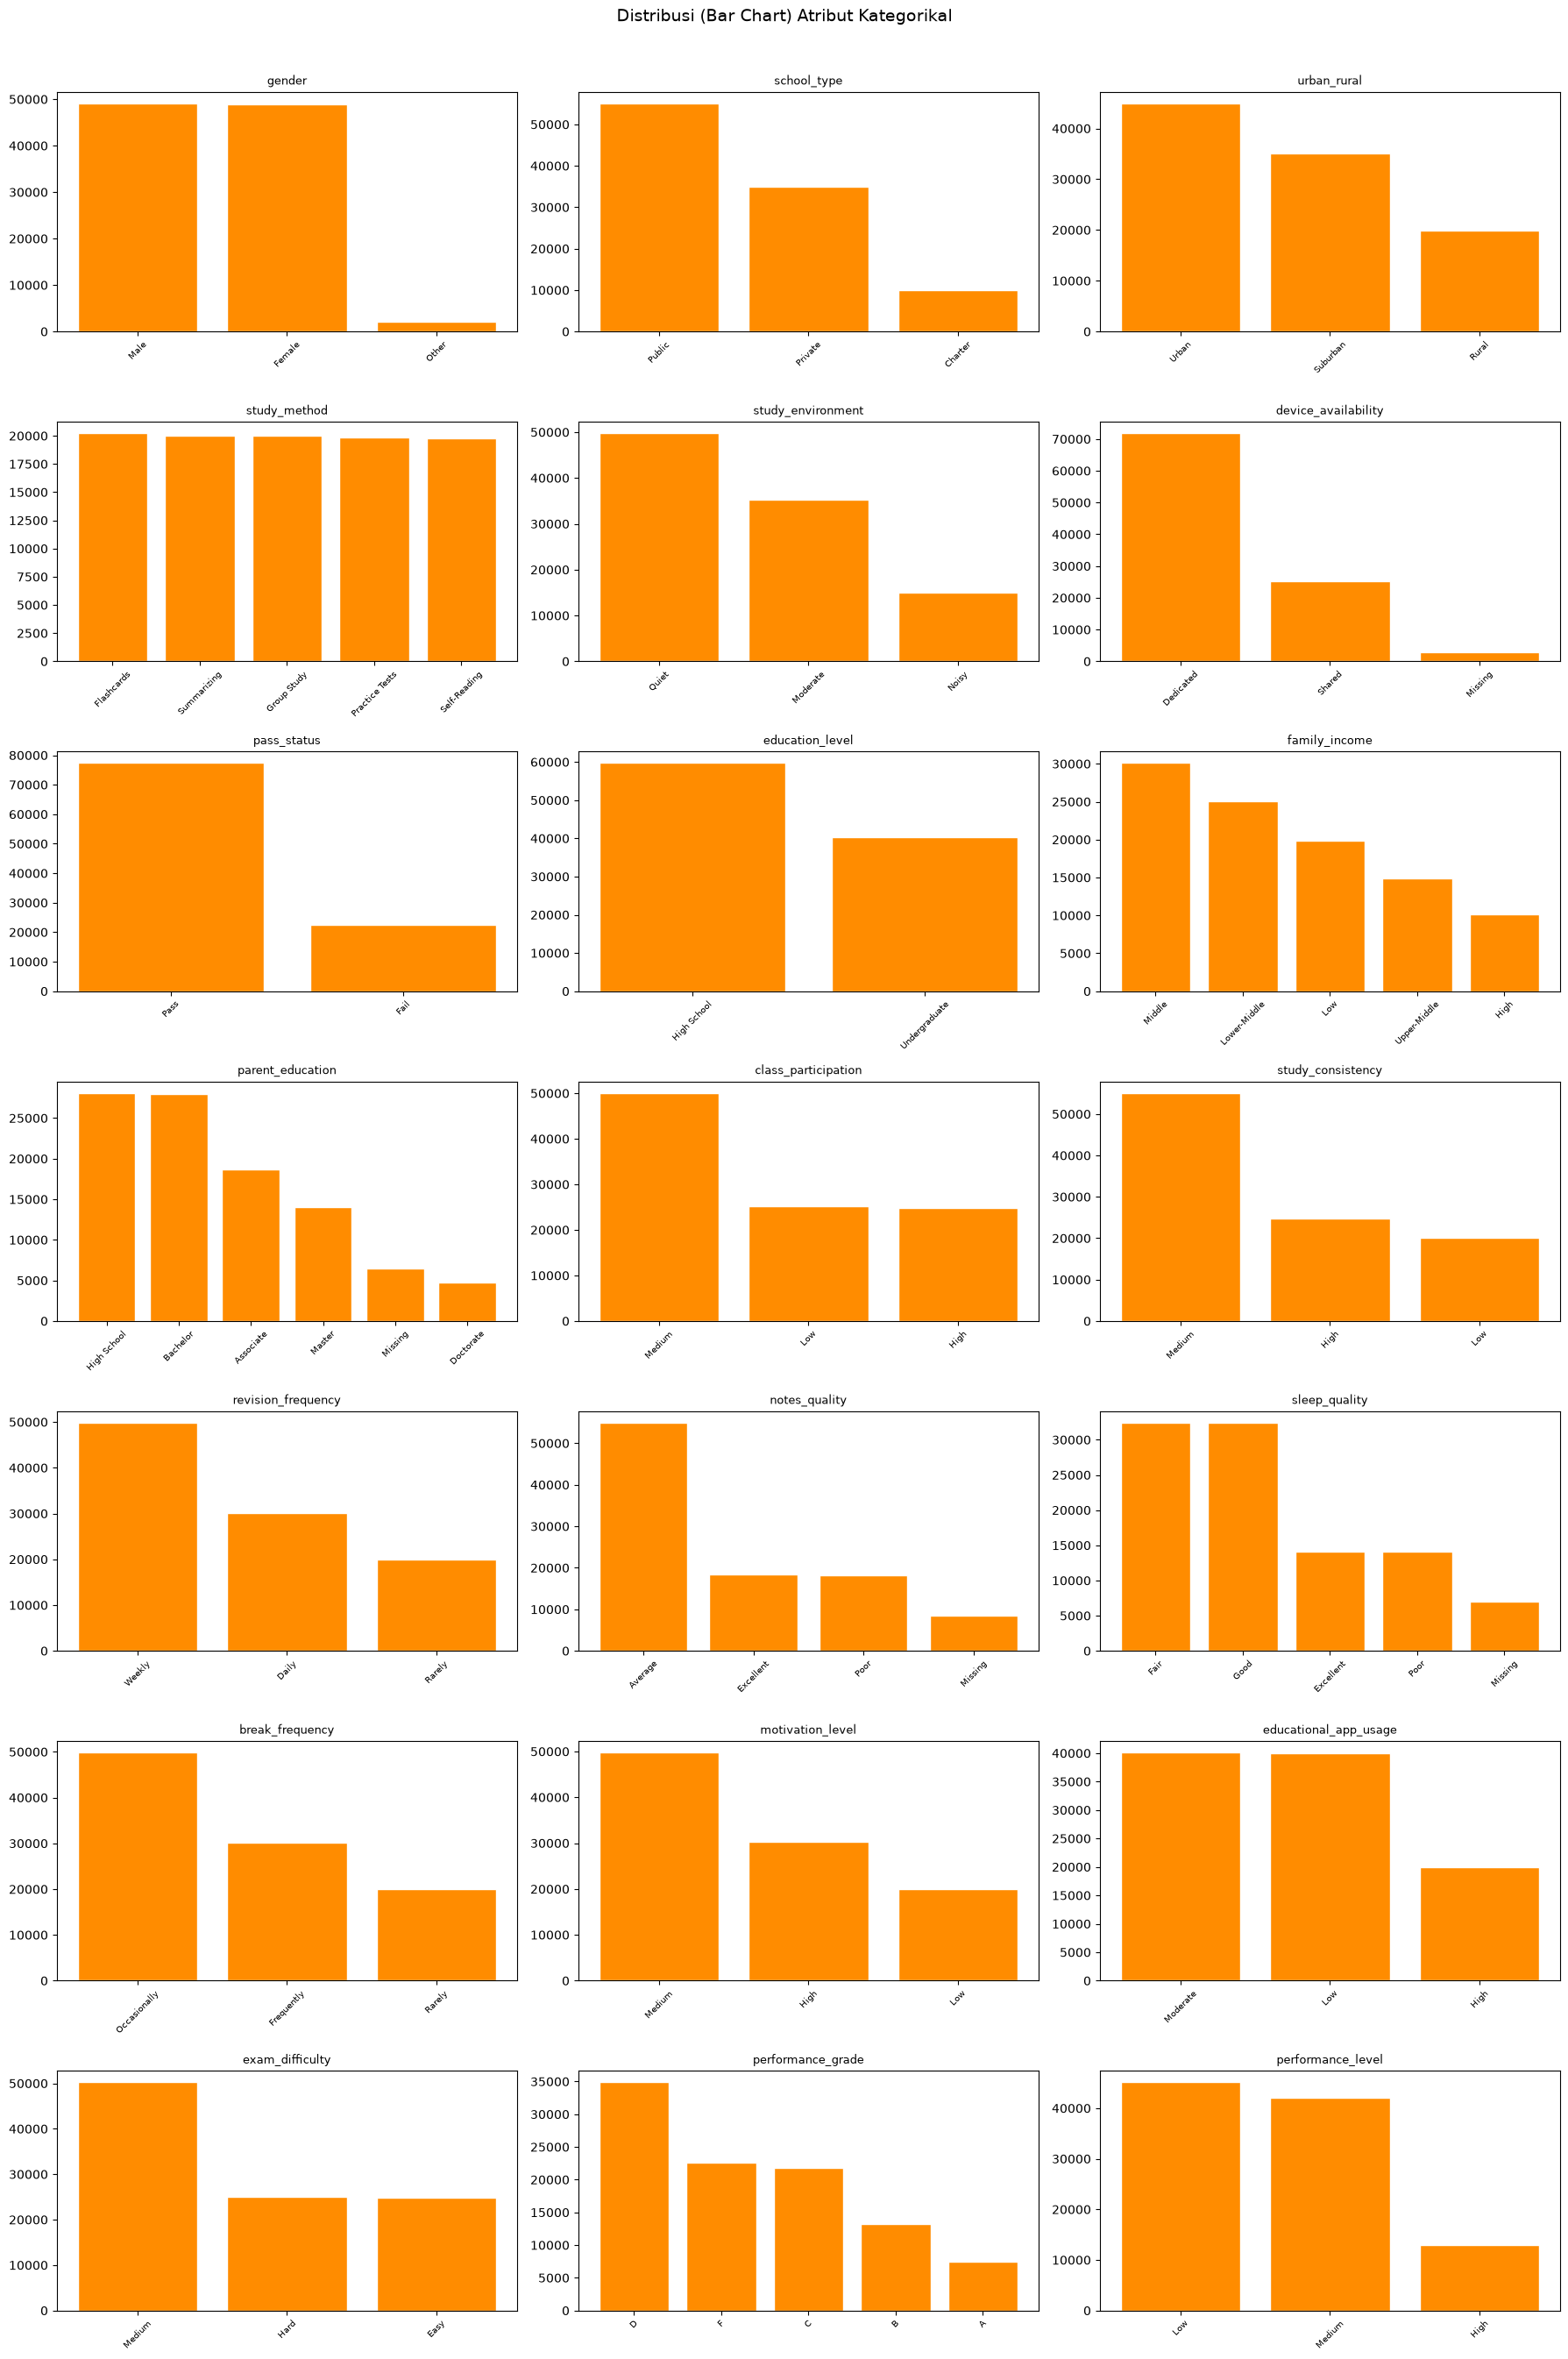

Kategori paling dominan untuk tiap atribut:
- gender: 'Male' (49.13%)
- school_type: 'Public' (55.1%)
- urban_rural: 'Urban' (44.96%)
- study_method: 'Flashcards' (20.24%)
- study_environment: 'Quiet' (49.79%)
- device_availability: 'Dedicated' (71.86%)
- pass_status: 'Pass' (77.39%)
- education_level: 'High School' (59.75%)
- family_income: 'Middle' (30.11%)
- parent_education: 'High School' (28.12%)
- class_participation: 'Medium' (50.11%)
- study_consistency: 'Medium' (55.14%)
- revision_frequency: 'Weekly' (49.87%)
- notes_quality: 'Average' (54.97%)
- sleep_quality: 'Fair' (32.44%)
- break_frequency: 'Occasionally' (49.87%)
- motivation_level: 'Medium' (49.78%)
- educational_app_usage: 'Moderate' (40.13%)
- exam_difficulty: 'Medium' (50.24%)
- performance_grade: 'D' (34.89%)
- performance_level: 'Low' (45.12%)

Interpretasi: Atribut 'pass_status' memiliki dominasi kategori tertinggi, yaitu 'Pass' yang mencakup 77.39% dari seluruh data. Atribut dengan satu kategori yang sangat domi

In [13]:
n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 3.8 * n_rows))
axes = axes.flatten()

dominant_info = {}
for i, col in enumerate(categorical_cols):
    counts = data[col].value_counts(dropna=False)
    labels = ["Missing" if pd.isna(v) else str(v) for v in counts.index]
    axes[i].bar(labels, counts.values, color="darkorange", edgecolor="white")
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(axis="x", rotation=45, labelsize=7)
    dominant_info[col] = (str(counts.index[0]), round(counts.iloc[0] / counts.sum() * 100, 2))

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Distribusi (Bar Chart) Atribut Kategorikal", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("Kategori paling dominan untuk tiap atribut:")
for col, (cat, pct) in dominant_info.items():
    print(f"- {col}: '{cat}' ({pct}%)")

most_dominant_col = max(dominant_info, key=lambda c: dominant_info[c][1])
cat, pct = dominant_info[most_dominant_col]
print(f"\nInterpretasi: Atribut '{most_dominant_col}' memiliki dominasi kategori tertinggi, yaitu "
      f"'{cat}' yang mencakup {pct}% dari seluruh data. Atribut dengan satu kategori yang sangat "
      f"dominan cenderung kurang informatif untuk membedakan performa siswa, sementara atribut "
      f"dengan proporsi kategori yang lebih merata berpotensi lebih berguna sebagai fitur pembeda.")

### 6. Analisis Bivariat / Hubungan Antar Atribut

#### 6a. Correlation Heatmap (Atribut Numerik)

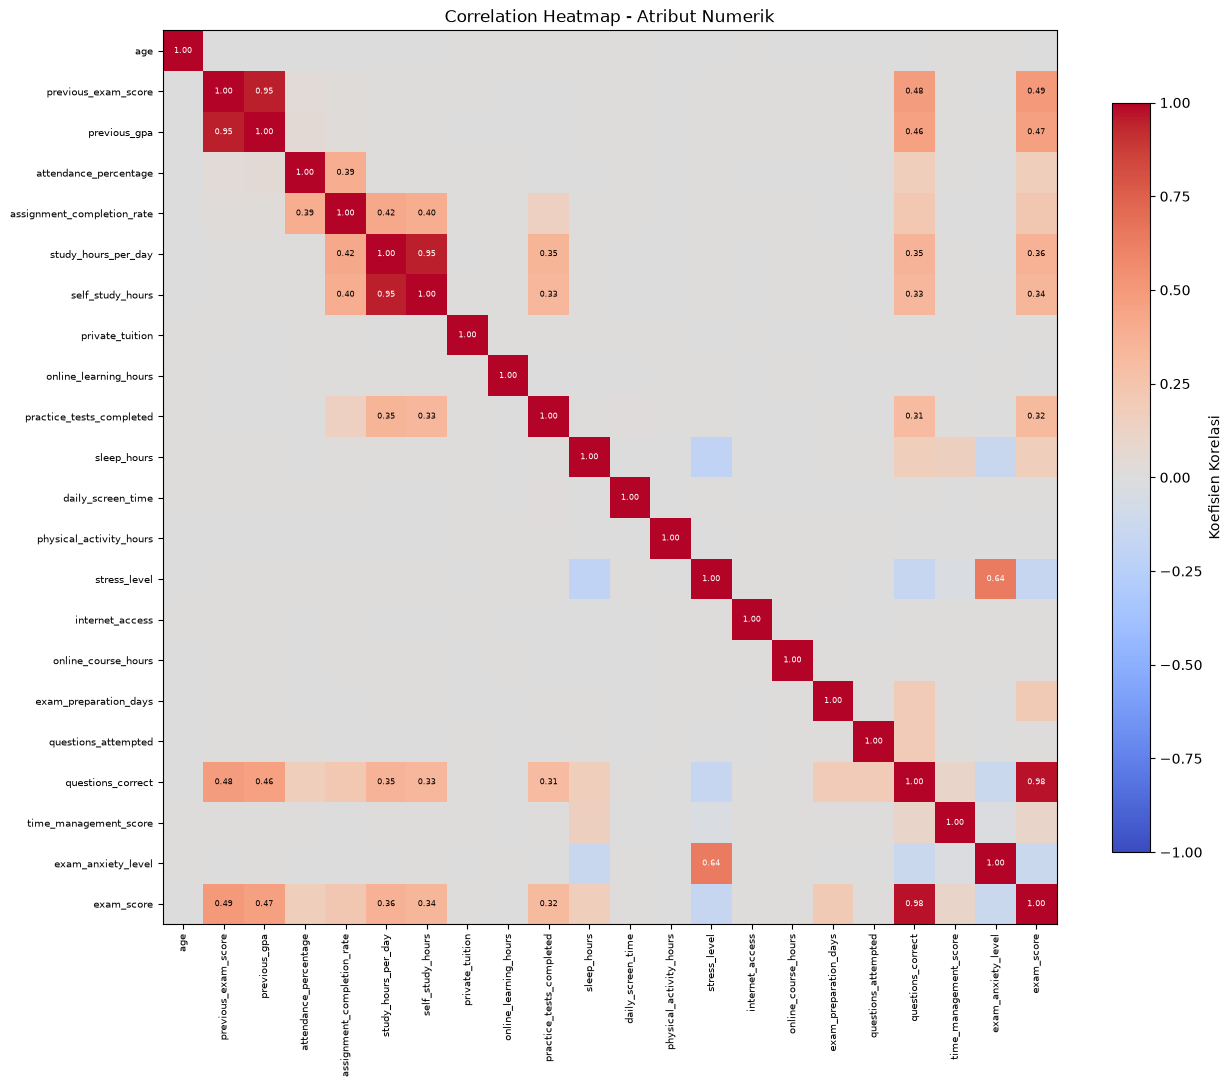

10 pasangan atribut numerik dengan korelasi (absolut) tertinggi:
exam_score                  questions_correct      0.975
previous_exam_score         previous_gpa           0.949
self_study_hours            study_hours_per_day    0.949
exam_anxiety_level          stress_level           0.636
exam_score                  previous_exam_score    0.494
previous_exam_score         questions_correct      0.482
exam_score                  previous_gpa           0.468
previous_gpa                questions_correct      0.456
assignment_completion_rate  study_hours_per_day    0.419
                            self_study_hours       0.396
dtype: float64

Interpretasi: Korelasi terkuat ditemukan antara 'exam_score' dan 'questions_correct' (r = 0.98), yaitu korelasi positif, artinya kedua atribut cenderung bergerak searah. Secara umum atribut numerik lainnya memiliki korelasi yang relatif lemah satu sama lain, menunjukkan performa siswa dipengaruhi banyak faktor yang relatif independen.


In [19]:
corr_matrix = data[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(numerical_cols)))
ax.set_yticks(range(len(numerical_cols)))
ax.set_xticklabels(numerical_cols, rotation=90, fontsize=7)
ax.set_yticklabels(numerical_cols, fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8, label="Koefisien Korelasi")

for i in range(len(numerical_cols)):
    for j in range(len(numerical_cols)):
        val = corr_matrix.iloc[i, j]
        if abs(val) >= 0.3:
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6,
                    color="white" if abs(val) > 0.6 else "black")

ax.set_title("Correlation Heatmap - Atribut Numerik")
plt.tight_layout()
plt.show()

corr_pairs = corr_matrix.where(~np.eye(len(numerical_cols), dtype=bool)).unstack().dropna()
corr_pairs = corr_pairs[corr_pairs.index.map(lambda x: x[0] < x[1])]
top_corr = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index).head(10)

print("10 pasangan atribut numerik dengan korelasi (absolut) tertinggi:")
print(top_corr.round(3))

pair1 = top_corr.index[0]
val1 = top_corr.iloc[0]
arah1 = "positif" if val1 > 0 else "negatif"
print(f"\nInterpretasi: Korelasi terkuat ditemukan antara '{pair1[0]}' dan '{pair1[1]}' "
      f"(r = {val1:.2f}), yaitu korelasi {arah1}, artinya kedua atribut cenderung bergerak "
      f"{'searah' if val1 > 0 else 'berlawanan arah'}. Secara umum atribut numerik lainnya "
      f"memiliki korelasi yang relatif lemah satu sama lain, menunjukkan performa siswa "
      f"dipengaruhi banyak faktor yang relatif independen.")

#### 6b. Scatter Plot antar Atribut Numerik

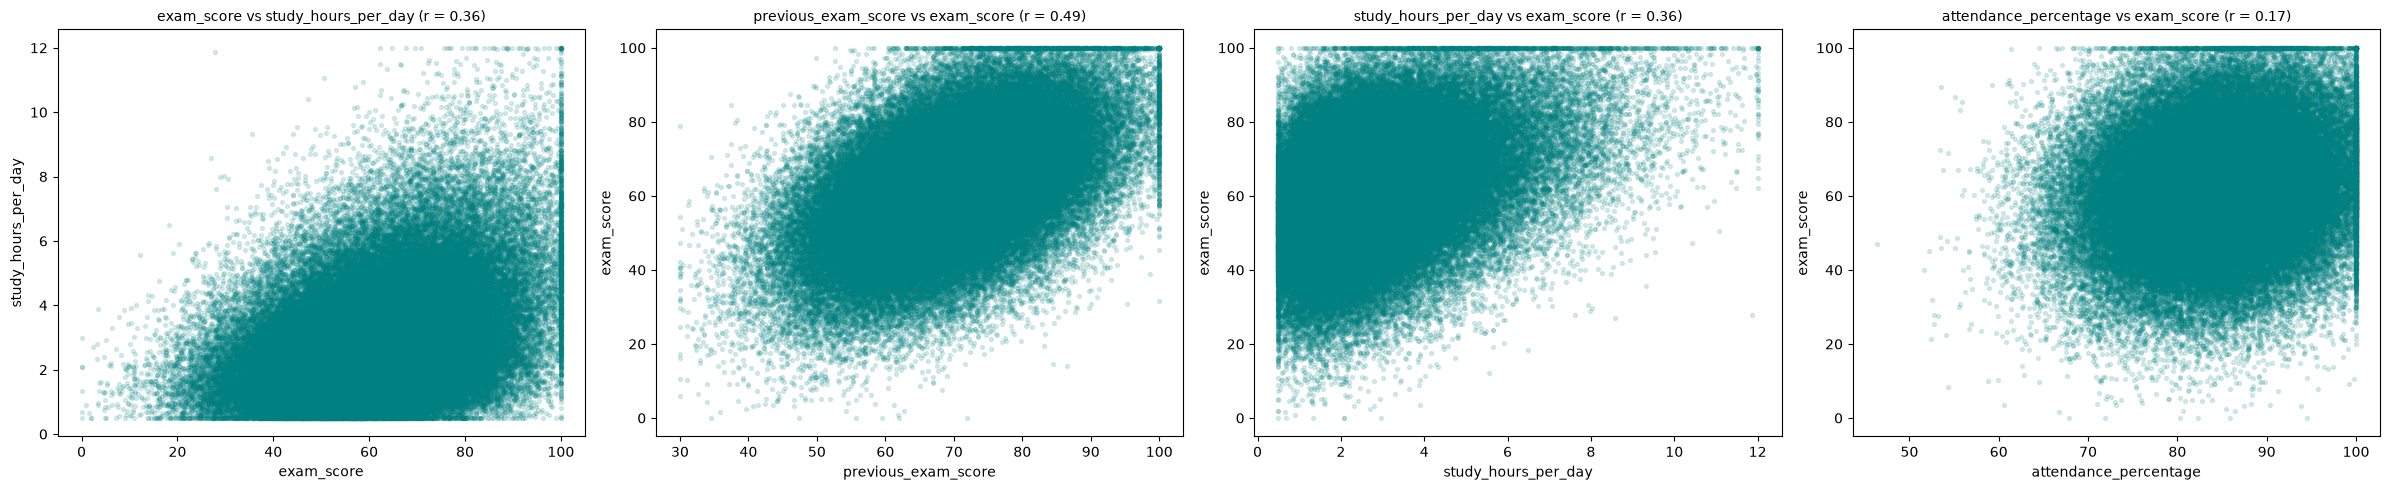

Interpretasi:
- 'exam_score' vs 'study_hours_per_day': r = 0.36, hubungan sedang dan positif. Semakin tinggi exam_score, study_hours_per_day cenderung semakin tinggi.
- 'previous_exam_score' vs 'exam_score': r = 0.49, hubungan sedang dan positif. Semakin tinggi previous_exam_score, exam_score cenderung semakin tinggi.
- 'study_hours_per_day' vs 'exam_score': r = 0.36, hubungan sedang dan positif. Semakin tinggi study_hours_per_day, exam_score cenderung semakin tinggi.
- 'attendance_percentage' vs 'exam_score': r = 0.17, hubungan lemah dan positif. Semakin tinggi attendance_percentage, exam_score cenderung semakin tinggi.


In [20]:
scatter_pairs = [
    ("exam_score", "study_hours_per_day"),
    ("previous_exam_score", "exam_score"),
    ("study_hours_per_day", "exam_score"),
    ("attendance_percentage", "exam_score"),
]

fig, axes = plt.subplots(1, len(scatter_pairs), figsize=(6 * len(scatter_pairs), 5))

r_values = {}
for ax, (x_col, y_col) in zip(axes, scatter_pairs):
    subset = data[[x_col, y_col]].dropna()
    ax.scatter(subset[x_col], subset[y_col], alpha=0.15, s=8, color="teal")
    r = subset[x_col].corr(subset[y_col])
    r_values[(x_col, y_col)] = r
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{x_col} vs {y_col} (r = {r:.2f})", fontsize=10)

plt.tight_layout()
plt.show()

print("Interpretasi:")
for (x_col, y_col), r in r_values.items():
    if abs(r) < 0.1:
        kekuatan = "sangat lemah / nyaris tidak ada hubungan linear"
    elif abs(r) < 0.3:
        kekuatan = "lemah"
    elif abs(r) < 0.6:
        kekuatan = "sedang"
    else:
        kekuatan = "kuat"
    if r > 0.1:
        pola = f"Semakin tinggi {x_col}, {y_col} cenderung semakin tinggi."
    elif r < -0.1:
        pola = f"Semakin tinggi {x_col}, {y_col} cenderung semakin rendah."
    else:
        pola = "Tidak terlihat pola hubungan linear yang jelas."
    arah = "positif" if r >= 0 else "negatif"
    print(f"- '{x_col}' vs '{y_col}': r = {r:.2f}, hubungan {kekuatan} dan {arah}. {pola}")

#### 6c. Boxplot Atribut Numerik per Kategori

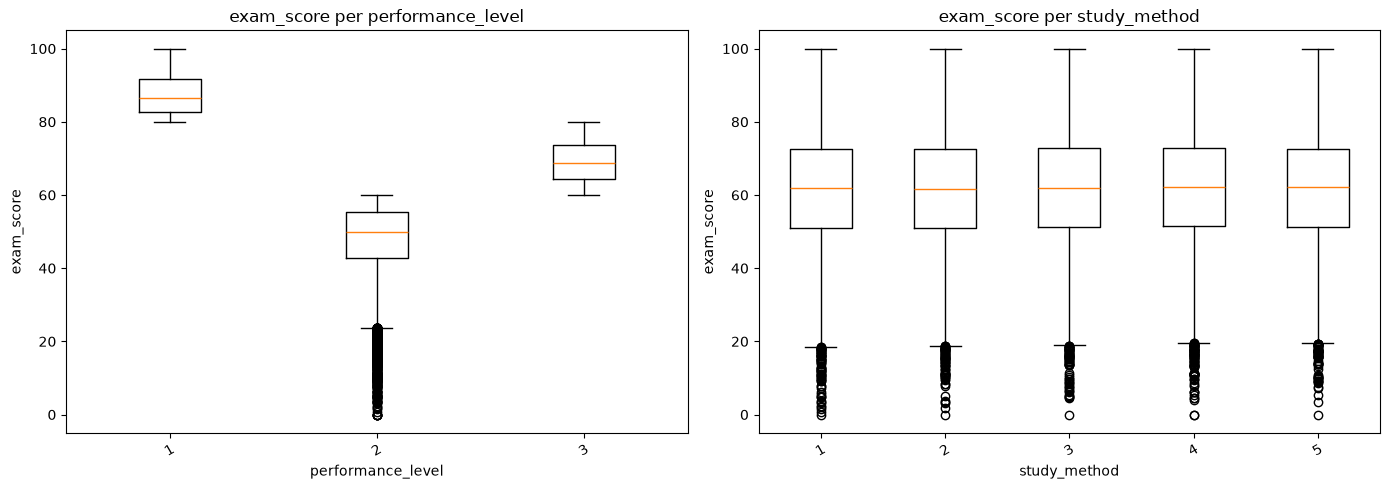

Interpretasi:
- 'exam_score' per 'performance_level': median tertinggi pada kategori 'High' (86.38), median terendah pada 'Low' (49.96). Selisih median sebesar 36.42 poin menunjukkan bahwa 'performance_level' cukup berpengaruh terhadap variasi nilai 'exam_score'.
- 'exam_score' per 'study_method': median tertinggi pada kategori 'Self-Reading' (62.15), median terendah pada 'Group Study' (61.77). Selisih median sebesar 0.38 poin menunjukkan bahwa 'study_method' kurang berpengaruh secara signifikan terhadap variasi nilai 'exam_score'.


In [22]:
box_configs = [
    ("performance_level", "exam_score"),
    ("study_method", "exam_score"),
]

fig, axes = plt.subplots(1, len(box_configs), figsize=(7 * len(box_configs), 5))

for ax, (cat_col, num_col) in zip(axes, box_configs):
    groups = data[[cat_col, num_col]].dropna()
    categories = sorted(groups[cat_col].unique())
    data_per_group = [groups.loc[groups[cat_col] == cat, num_col].values for cat in categories]
    ax.boxplot(data_per_group, label=categories)
    ax.set_xlabel(cat_col)
    ax.set_ylabel(num_col)
    ax.set_title(f"{num_col} per {cat_col}")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print("Interpretasi:")
for cat_col, num_col in box_configs:
    medians = data[[cat_col, num_col]].dropna().groupby(cat_col)[num_col].median().sort_values(ascending=False)
    highest_cat, lowest_cat = medians.index[0], medians.index[-1]
    selisih = medians.iloc[0] - medians.iloc[-1]
    pengaruh = "cukup berpengaruh" if selisih > 5 else "kurang berpengaruh secara signifikan"
    print(f"- '{num_col}' per '{cat_col}': median tertinggi pada kategori '{highest_cat}' "
          f"({medians.iloc[0]:.2f}), median terendah pada '{lowest_cat}' ({medians.iloc[-1]:.2f}). "
          f"Selisih median sebesar {selisih:.2f} poin menunjukkan bahwa '{cat_col}' {pengaruh} "
          f"terhadap variasi nilai '{num_col}'.")

### 7. Ringkasan

Interpretasi untuk setiap grafik pada bagian EDA di atas dicetak langsung di bawah masing-masing grafik (dihasilkan secara terprogram dari nilai statistik yang dihitung dari `data`), sehingga akan tetap relevan meskipun data diperbarui atau notebook dijalankan ulang.